In [ ]:
%pip install numpy
%pip install pandas
%pip install requests
%pip install beautifulsoup4
%pip install lxml
%pip install selenium webdriver-manager beautifulsoup4

In [16]:
import pandas as pd
import numpy as np
import re

## House Rent Prediction – Data Preprocessing
This project aims to build a machine learning model that can predict house rental prices based on different property features such as location, number of bedrooms, furnishing status, and built area.

The dataset used in this project was collected through web scraping from MagicBricks, a popular real estate platform in India. Rental property data was scraped for multiple major cities including:

* Mumbai
* Kolkata
* Bangalore
* New Delhi
* Hyderabad
* Chennai
* Ahmedabad
* Pune
* Surat
* Noida
* Surat
* Gurgaon

Since the raw scraped data may contain duplicate listings and inconsistencies, a data preprocessing pipeline is implemented to clean and consolidate the datasets before performing exploratory data analysis (EDA) and model development.

In [17]:
cities=["mumbai","kolkata","bangalore","new-delhi","hyderabad","chennai","ahmedabad","pune"]

In [18]:
for city in cities:
    df = pd.read_csv(f"Data\{city}_rent_data.csv")
    print("Original Shape:", df.shape)
    duplicates = df.duplicated().sum()
    print("Duplicate rows:", duplicates)
    df = df.drop_duplicates()
    print("New Shape after removing duplicates:", df.shape)
    df.to_csv(f"Data\{city}_rent_data.csv", index=False)
    print("Dataset cleaned and saved.",end="\n\n")

Original Shape: (2972, 50)
Duplicate rows: 0
New Shape after removing duplicates: (2972, 50)
Dataset cleaned and saved.

Original Shape: (3026, 53)
Duplicate rows: 0
New Shape after removing duplicates: (3026, 53)
Dataset cleaned and saved.

Original Shape: (3027, 54)
Duplicate rows: 0
New Shape after removing duplicates: (3027, 54)
Dataset cleaned and saved.

Original Shape: (3026, 46)
Duplicate rows: 0
New Shape after removing duplicates: (3026, 46)
Dataset cleaned and saved.

Original Shape: (3026, 55)
Duplicate rows: 0
New Shape after removing duplicates: (3026, 55)
Dataset cleaned and saved.

Original Shape: (3022, 55)
Duplicate rows: 0
New Shape after removing duplicates: (3022, 55)
Dataset cleaned and saved.

Original Shape: (3006, 51)
Duplicate rows: 0
New Shape after removing duplicates: (3006, 51)
Dataset cleaned and saved.

Original Shape: (3030, 51)
Duplicate rows: 0
New Shape after removing duplicates: (3030, 51)
Dataset cleaned and saved.



In [19]:
total_df=pd.DataFrame()
for city in cities:
    df = pd.read_csv(f"Data\{city}_rent_data.csv")
    total_df=pd.concat([total_df,df],ignore_index=True)

In [20]:
total_df.to_csv(f"Data\{len(cities)}_rent_data.csv")

In [21]:
total_data=pd.read_csv(f"Data\{len(cities)}_rent_data.csv")
df=total_data.copy()

C:\Users\USER\AppData\Local\Temp\ipykernel_13164\934210423.py:1: DtypeWarning: Columns (56) have mixed types. Specify dtype option on import or set low_memory=False.
  total_data=pd.read_csv(f"Data\{len(cities)}_rent_data.csv")


### Messy data
1. Built area and carpet area will be in same columns
2. Carper area and super area are complemnt to each other .They will be in same columns
3. Plot area and carpet area is not same.
4. Immediately and under construction will be in same columns
### Tiedy Data
1. Area are in different type with different units(sqft,sqm,sqyard)
2. Prize is in obect type with mixed unit lakh and thousand will be in same unit 
3. Bathroom will be integers
4. Balcony will be in integers

### Delete columns which has missing data more than 97%

In [22]:
df=df.sample(len(df))

In [23]:
df.head()

,Unnamed: 0,Title,Rental_Price,Location,Bed,Baths,Carpet Area,Floor,Status,Furnished Status,...,Any Construction done,Boundary Wall,Transaction Type,Additional Features,Approved,Floor allowed,No of Open Sides,Dimensions(L X B),Brokerage Response,Floors Allowed For Construction
17432,17432,4 BHK Residential House For Rent,"₹27,000","Iyyappanthangal, Chennai",NaN,3.0,1276sqftsqftsqyrdsqmacrebighahectaremarlakanal...,NaN,Immediately,Semi-Furnished,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
15876,15876,3 BHK Residential House For Rent,"₹23,000","Pammal, Chennai",NaN,2.0,1150sqftsqftsqyrdsqmacrebighahectaremarlakanal...,Ground(Out of 2 Floors),Immediately,Semi-Furnished,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
3041,3041,2 BHK Flat 700 Sq-ft For Rent in,"₹11,000","Maa manasha Apartment, Madhugarh, Dumdum, Kolkata",NaN,2.0,NaN,1(Out of 4 Floors),Immediately,Unfurnished,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
19698,19698,3 BHK 2200 Sq-ft Flat/Apartment For Rent in K...,"₹35,000","kavisha the canvas, Ahmedabad",NaN,3.0,1200sqftsqftsqyrdsqmacrebighahectaremarlakanal...,2(Out of 14 Floors),Immediately,Semi-Furnished,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
14773,14773,2 BHK Flat 1150 Sq-ft For Rent in SVS Ample Ho...,"₹30,000","Chanda Nagar, Hyderabad",NaN,2.0,NaN,3(Out of 5 Floors),Immediately,Semi-Furnished,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN


In [24]:
df=df.drop(columns=['Unnamed: 0'])

In [25]:
df.info()

<class 'pandas.core.frame.DataFrame'>
Index: 24135 entries, 17432 to 16292
Data columns (total 57 columns):
 #   Column                           Non-Null Count  Dtype  
---  ------                           --------------  -----  
 0   Title                            24135 non-null  object 
 1   Rental_Price                     24135 non-null  object 
 2   Location                         24135 non-null  object 
 3   Bed                              3734 non-null   float64
 4   Baths                            19552 non-null  float64
 5   Carpet Area                      15572 non-null  object 
 6   Floor                            20497 non-null  object 
 7   Status                           23285 non-null  object 
 8   Furnished Status                 23831 non-null  object 
 9   Rental Value                     23642 non-null  object 
 10  Security Deposit                 16735 non-null  object 
 11  Address                          24135 non-null  object 
 12  Furnishing         

In [12]:
df.head()

,Title,Rental_Price,Location,Bed,Baths,Carpet Area,Floor,Status,Furnished Status,Rental Value,...,Any Construction done,Boundary Wall,Transaction Type,Additional Features,Approved,Floor allowed,No of Open Sides,Dimensions(L X B),Brokerage Response,Floors Allowed For Construction
1621,1 BHK 650 Sq-ft Flat/Apartment For Rent in GH...,"₹39,000","Powai, Mumbai",1.0,2.0,450sqftsqftsqyrdsqmacrebighahectaremarlakanalb...,6(Out of 16 Floors),Immediately,Furnished,"₹39,000",...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
22662,2 BHK 1250 Sq-ft Flat/Apartment For Rent in A...,"₹45,000","Amanora Park Town, Pune",NaN,2.0,989sqftsqftsqyrdsqmacrebighahectaremarlakanalb...,1(Out of 1 Floors),Immediately,Furnished,"₹45,000",...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
10136,2 BHK 830 Sq-ft Flat/Apartment For Rent in JV...,"₹19,000","Chhattarpur, New Delhi",NaN,2.0,800sqftsqftsqyrdsqmacrebighahectaremarlakanalb...,2(Out of 5 Floors),Immediately,Semi-Furnished,"₹19,000|₹1,000Monthly Maintenance",...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
9233,4 BHK Builder Floor 311 Sq-yrd For Rent in,₹1.7 Lac,"Hauz Khas, New Delhi",NaN,4.0,311sqyrdsqftsqyrdsqmacrebighahectaremarlakanal...,1(Out of 1 Floors),Immediately,Unfurnished,"₹1.7 Lac|₹7,000Monthly Maintenance",...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
13384,2 BHK Flat 1190 Sq-ft For Rent in Phoenix Golf...,"₹27,000","Gachibowli, Hyderabad",NaN,2.0,1150sqftsqftsqyrdsqmacrebighahectaremarlakanal...,8(Out of 30 Floors),Immediately,Furnished,"₹27,000|₹3,000Monthly Maintenance",...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN


In [13]:
df[df['Carpet Area'].notna()].sample(3).transpose() # checking the data in specific cols

,6504,20110,2766
Title,2 BHK Builder Floor 1000 Sq-ft For Rent in,3 BHK 1651 Sq-ft Flat/Apartment For Rent in C...,1 BHK 650 Sq-ft Flat/Apartment For Rent in
Rental_Price,"₹45,000","₹36,000","₹35,000"
Location,"Halasuru, Bangalore","Shilaj, Ahmedabad","Andheri West, Mumbai"
Bed,NaN,NaN,1.0
Baths,2.0,3.0,2.0
Carpet Area,800sqftsqftsqyrdsqmacrebighahectaremarlakanalb...,742sqftsqftsqyrdsqmacrebighahectaremarlakanalb...,565sqftsqftsqyrdsqmacrebighahectaremarlakanalb...
Floor,1(Out of 6 Floors),10(Out of 14 Floors),4(Out of 7 Floors)
Status,Immediately,Immediately,Immediately
Furnished Status,Semi-Furnished,Unfurnished,Semi-Furnished
Rental Value,"₹45,000|₹3,000Monthly Maintenance","₹36,000","₹35,000"


In [ ]:
mask1 = df["Super Area"].notna()
df.loc[mask1, "Carpet Area"] = df.loc[mask1, "Super Area"]

In [ ]:
mask2 = df["Built Area"].notna()
df.loc[mask2, "Carpet Area"] = df.loc[mask2, "Built Area"]

In [ ]:
df=df.drop(["Built Area","Super Area"],axis=1)

In [ ]:
df.info()

<class 'pandas.core.frame.DataFrame'>
Index: 32645 entries, 8522 to 4558
Data columns (total 25 columns):
 #   Column                           Non-Null Count  Dtype  
---  ------                           --------------  -----  
 0   Title                            32645 non-null  object 
 1   Owner                            31236 non-null  object 
 2   Price                            32645 non-null  object 
 3   Furnishing                       32230 non-null  object 
 4   Bathroom                         32275 non-null  object 
 5   Tenant Preferred                 32589 non-null  object 
 6   Availability                     32547 non-null  object 
 7   Floor                            27850 non-null  object 
 8   facing                           22478 non-null  object 
 9   Society                          11840 non-null  object 
 10  Balcony                          24243 non-null  object 
 11  Carpet Area                      32335 non-null  object 
 12  overlooking          

In [ ]:
df=df.drop_duplicates()
print(df.duplicated().sum())

0


In [ ]:
mask3 = df["Under Construction"].notna()
df.loc[mask3, "Immediately"] = df.loc[mask3, "Under Construction"]
df=df.drop(["Under Construction"],axis=1)

In [ ]:
df.info()

<class 'pandas.core.frame.DataFrame'>
Index: 32644 entries, 8522 to 4558
Data columns (total 24 columns):
 #   Column                           Non-Null Count  Dtype  
---  ------                           --------------  -----  
 0   Title                            32644 non-null  object 
 1   Owner                            31235 non-null  object 
 2   Price                            32644 non-null  object 
 3   Furnishing                       32229 non-null  object 
 4   Bathroom                         32274 non-null  object 
 5   Tenant Preferred                 32588 non-null  object 
 6   Availability                     32546 non-null  object 
 7   Floor                            27849 non-null  object 
 8   facing                           22477 non-null  object 
 9   Society                          11839 non-null  object 
 10  Balcony                          24242 non-null  object 
 11  Carpet Area                      32334 non-null  object 
 12  overlooking          

In [ ]:
df[df['Dimensions'].notna()].sample(3).transpose()    # only for checking each columns individually 

,14731,16310,5724
Title,3 BHK House for Rent in MRF Colony Sangareddy...,4 BHK Villa for Rent in Uthandi Chennai,2 BHK House for Rent in Kestopur Kolkata
Owner,Owner: K ANILKUMAR,Owner: Ramesh,Owner: SIBO MONDAL
Price,"₹17,000",₹1.6 Lac,"₹10,000"
Furnishing,Semi-Furnished,Furnished,Unfurnished
Bathroom,3,5,1
Tenant Preferred,Family,Bachelors,Bachelors/Family
Availability,Immediately,Immediately,Immediately
Floor,NaN,NaN,1 out of 2
facing,East,North - East,North
Society,NaN,NaN,NaN


In [ ]:
# Calculate minimum number of non-missing values required (3% of total rows)
threshold = int(0.03 * len(df))

# Drop columns that have non-missing values less than the threshold
df = df.dropna(axis=1, thresh=threshold)

print("\nNew Dataset Shape:",df.shape)


New Dataset Shape: (32644, 14)


In [ ]:
df.info()

<class 'pandas.core.frame.DataFrame'>
Index: 32644 entries, 8522 to 4558
Data columns (total 14 columns):
 #   Column            Non-Null Count  Dtype 
---  ------            --------------  ----- 
 0   Title             32644 non-null  object
 1   Owner             31235 non-null  object
 2   Price             32644 non-null  object
 3   Furnishing        32229 non-null  object
 4   Bathroom          32274 non-null  object
 5   Tenant Preferred  32588 non-null  object
 6   Availability      32546 non-null  object
 7   Floor             27849 non-null  object
 8   facing            22477 non-null  object
 9   Society           11839 non-null  object
 10  Balcony           24242 non-null  object
 11  Carpet Area       32334 non-null  object
 12  overlooking       21477 non-null  object
 13  Ownership         2817 non-null   object
dtypes: object(14)
memory usage: 3.7+ MB


In [ ]:
def clean_price(x):

    if pd.isna(x):
        return np.nan

    x = str(x).lower().replace(',', '').replace('₹','').strip()

    # handle ranges like "15000 - 20000"
    if "-" in x:
        x = x.split("-")[0]

    # extract numeric value
    num = re.findall(r'\d+\.?\d*', x)
    if not num:
        return np.nan

    value = float(num[0])

    # unit conversion
    if "lac" in x or "lakh" in x:
        value = value * 100000
    elif "crore" in x or "cr" in x:
        value = value * 10000000
    elif "k" in x or "thousand" in x:
        value = value * 1000

    return value


df["Price"] = df["Price"].apply(clean_price).astype(float)

In [ ]:
df.info()

<class 'pandas.core.frame.DataFrame'>
Index: 32644 entries, 8522 to 4558
Data columns (total 14 columns):
 #   Column            Non-Null Count  Dtype  
---  ------            --------------  -----  
 0   Title             32644 non-null  object 
 1   Owner             31235 non-null  object 
 2   Price             32047 non-null  float64
 3   Furnishing        32229 non-null  object 
 4   Bathroom          32274 non-null  object 
 5   Tenant Preferred  32588 non-null  object 
 6   Availability      32546 non-null  object 
 7   Floor             27849 non-null  object 
 8   facing            22477 non-null  object 
 9   Society           11839 non-null  object 
 10  Balcony           24242 non-null  object 
 11  Carpet Area       32334 non-null  object 
 12  overlooking       21477 non-null  object 
 13  Ownership         2817 non-null   object 
dtypes: float64(1), object(13)
memory usage: 3.7+ MB


In [ ]:
def clean_area(x):

    if pd.isna(x):
        return np.nan

    x = str(x).lower().strip().replace(',', '')

    # extract numeric value
    num = re.findall(r'\d+\.?\d*', x)
    if not num:
        return np.nan

    value = float(num[0])

    # unit conversions → sqft
    if "sq.m" in x or "sqm" in x or "m²" in x:
        value = value * 10.7639
    elif "sqyd" in x or "sq.yd" in x or "yd²" in x:
        value = value * 9
    elif "acre" in x:
        value = value * 43560
    elif "hectare" in x:
        value = value * 107639
    # sqft case (default)
    
    return value


df["Carpet Area"] = df["Carpet Area"].apply(clean_area).astype(float)

In [ ]:
df.info()

<class 'pandas.core.frame.DataFrame'>
Index: 32644 entries, 8522 to 4558
Data columns (total 14 columns):
 #   Column            Non-Null Count  Dtype  
---  ------            --------------  -----  
 0   Title             32644 non-null  object 
 1   Owner             31235 non-null  object 
 2   Price             32047 non-null  float64
 3   Furnishing        32229 non-null  object 
 4   Bathroom          32274 non-null  object 
 5   Tenant Preferred  32588 non-null  object 
 6   Availability      32546 non-null  object 
 7   Floor             27849 non-null  object 
 8   facing            22477 non-null  object 
 9   Society           11839 non-null  object 
 10  Balcony           24242 non-null  object 
 11  Carpet Area       32334 non-null  float64
 12  overlooking       21477 non-null  object 
 13  Ownership         2817 non-null   object 
dtypes: float64(2), object(12)
memory usage: 3.7+ MB


In [ ]:
cols = ["Bathroom", "Balcony"]

for col in cols:
    df[col] = df[col].astype(str).str.extract(r"(\d+)")[0].astype(float)

In [ ]:
df.info()

<class 'pandas.core.frame.DataFrame'>
Index: 32644 entries, 8522 to 4558
Data columns (total 14 columns):
 #   Column            Non-Null Count  Dtype  
---  ------            --------------  -----  
 0   Title             32644 non-null  object 
 1   Owner             31235 non-null  object 
 2   Price             32047 non-null  float64
 3   Furnishing        32229 non-null  object 
 4   Bathroom          32274 non-null  float64
 5   Tenant Preferred  32588 non-null  object 
 6   Availability      32546 non-null  object 
 7   Floor             27849 non-null  object 
 8   facing            22477 non-null  object 
 9   Society           11839 non-null  object 
 10  Balcony           24242 non-null  float64
 11  Carpet Area       32334 non-null  float64
 12  overlooking       21477 non-null  object 
 13  Ownership         2817 non-null   object 
dtypes: float64(4), object(10)
memory usage: 3.7+ MB


# Feature Engineering 
1. Three new columns from `Tittle` column namely `bhk` , `city`,`bhk_type` which contains number of bhk,the city name where the rental location is situated,bhk type means aparment,house etc respectively
2. Three new columns from `Floor` column namely `actual_floor`,`total_floor`,`floor_ratio` which contains the floor number of the rental place,total number in the flat,ratio of the total flat number and the rental floor.
3. One new column from `Owner` col

In [24]:
def process_floor(value):
    
    if pd.isna(value):
        return pd.Series([np.nan, np.nan])
    
    value = str(value)
    
    # handle basement and ground
    value = value.replace("Lower Basement", "-2")
    value = value.replace("Upper Basement", "-1")
    value = value.replace("Ground", "0")
    
    # remove "+"
    value = value.replace("+", "")
    
    # case: "x out of y"
    match = re.search(r'(-?\d+)\s*out of\s*(\d+)', value)
    
    if match:
        actual = int(match.group(1))
        total = int(match.group(2))
        return pd.Series([actual, total])
    
    # case: only one number present
    match2 = re.search(r'-?\d+', value)
    
    if match2:
        return pd.Series([int(match2.group()), np.nan])
    
    return pd.Series([np.nan, np.nan])


df[["actual_floor","total_floor"]] = df["Floor"].apply(process_floor).astype(float)

In [25]:
df["owner_type"] = df["Owner"].str.extract(r'^(owner|agent)', flags=re.I, expand=False).str.capitalize()

In [26]:
df=df.drop(columns=["Floor","Owner"])

In [27]:
# convert to string
df["Title"] = df["Title"].astype(str)

# -------- Extract BHK --------

df["bhk"] = df["Title"].str.extract(r'(\d+)\s*\+?\s*BHK', expand=False)

# handle RK and Studio
df.loc[df["Title"].str.contains("RK", case=False, na=False), "bhk"] = 1
df.loc[df["Title"].str.contains("Studio", case=False, na=False), "bhk"] = 1

df["bhk"] = pd.to_numeric(df["bhk"], errors="coerce").astype(float)


# -------- Extract City --------

df["city"] = df["Title"].str.split(" ").str[-1]

# extract property type
df["bhk_type"] = df["Title"].str.extract(r'BHK\s+([A-Za-z\s]+?)\s+for')

In [28]:
df.info()

<class 'pandas.core.frame.DataFrame'>
Index: 32644 entries, 8522 to 4558
Data columns (total 18 columns):
 #   Column            Non-Null Count  Dtype  
---  ------            --------------  -----  
 0   Title             32644 non-null  object 
 1   Price             32047 non-null  float64
 2   Furnishing        32229 non-null  object 
 3   Bathroom          32274 non-null  float64
 4   Tenant Preferred  32588 non-null  object 
 5   Availability      32546 non-null  object 
 6   facing            22477 non-null  object 
 7   Society           11839 non-null  object 
 8   Balcony           24242 non-null  float64
 9   Carpet Area       32334 non-null  float64
 10  overlooking       21477 non-null  object 
 11  Ownership         2817 non-null   object 
 12  actual_floor      27849 non-null  float64
 13  total_floor       27837 non-null  float64
 14  owner_type        31234 non-null  object 
 15  bhk               32389 non-null  float64
 16  city              32644 non-null  object 
 

In [29]:
df.sample(3).transpose()

,4176,24897,20035
Title,2 BHK Apartment for Rent in Sonarpur Kolkata,3 BHK Apartment for Rent in Rudrapur Bhubaneswar,3 BHK Apartment for Rent in Thaltej Ahmedabad
Price,10000.0,30000.0,52000.0
Furnishing,Unfurnished,Furnished,Furnished
Bathroom,2.0,2.0,3.0
Tenant Preferred,Bachelors/Family,Bachelors,Family
Availability,Immediately,Immediately,Immediately
facing,NaN,East,East
Society,NaN,Assotech Pride,Suyog Residency
Balcony,1.0,2.0,1.0
Carpet Area,636.0,950.0,1430.0


In [30]:
df.describe()

,Price,Bathroom,Balcony,Carpet Area,actual_floor,total_floor,bhk
count,3.204700e+04,32274.000000,24242.000000,32334.000000,27849.000000,27837.000000,32389.000000
mean,7.939660e+04,2.423065,1.888128,1337.428987,5.871845,11.849517,2.436043
std,8.397405e+05,1.082811,1.040308,2429.496496,6.403218,10.827931,1.038067
min,1.000000e+03,1.000000,1.000000,1.000000,-2.000000,1.000000,1.000000
25%,2.000000e+04,2.000000,1.000000,725.000000,2.000000,4.000000,2.000000
50%,3.400000e+04,2.000000,2.000000,1100.000000,4.000000,9.000000,2.000000
75%,6.500000e+04,3.000000,2.000000,1600.000000,8.000000,16.000000,3.000000
max,1.200000e+08,10.000000,10.000000,344334.000000,75.000000,200.000000,10.000000


# Missing Data Filling  

In [3]:
%pip install ydata-profiling

Note: you may need to restart the kernel to use updated packages.


ERROR: Ignored the following versions that require a different python version: 4.0.0 Requires-Python >=3.7,<3.11; 4.1.0 Requires-Python >=3.7,<3.12; 4.1.1 Requires-Python >=3.7,<3.12; 4.1.2 Requires-Python >=3.7,<3.12; 4.10.0 Requires-Python >=3.7,<3.13; 4.11.0 Requires-Python >=3.7,<3.13; 4.12.0 Requires-Python >=3.7,<3.13; 4.12.1 Requires-Python >=3.7,<3.13; 4.12.2 Requires-Python >=3.7,<3.13; 4.13.0 Requires-Python >=3.7,<3.13; 4.14.0 Requires-Python >=3.7,<3.13; 4.15.0 Requires-Python >=3.7,<3.13; 4.15.1 Requires-Python >=3.7,<3.13; 4.16.0 Requires-Python >=3.7,<3.13; 4.16.1 Requires-Python >=3.7,<3.13; 4.17.0 Requires-Python >=3.7,<3.14; 4.18.0 Requires-Python >=3.10,<3.14; 4.18.1 Requires-Python >=3.10,<3.14; 4.2.0 Requires-Python >=3.7,<3.12; 4.3.0 Requires-Python >=3.7,<3.12; 4.3.1 Requires-Python >=3.7,<3.12; 4.3.2 Requires-Python >=3.7,<3.12; 4.4.0 Requires-Python >=3.7,<3.12; 4.5.0 Requires-Python >=3.7,<3.12; 4.5.1 Requires-Python >=3.7,<3.12; 4.6.0 Requires-Python >=3.7,<3

In [4]:
from ydata_profiling import ProfileReport

ModuleNotFoundError: No module named 'ydata_profiling'

In [33]:
profile=ProfileReport(df)
profile.to_file('report.html')

Summarize dataset:   0%|          | 0/5 [00:00<?, ?it/s]


%|                                                                                           | 0/18 [00:00<?, ?it/s]
100%|██████████████████████████████████████████████████████████████████████████████████| 18/18 [00:00<00:00, 37.39it/s]


Generate report structure:   0%|          | 0/1 [00:00<?, ?it/s]

Render HTML:   0%|          | 0/1 [00:00<?, ?it/s]

Export report to file:   0%|          | 0/1 [00:00<?, ?it/s]

In [34]:
df.isnull().sum()/len(df)*100

Title                0.000000
Price                1.828820
Furnishing           1.271290
Bathroom             1.133440
Tenant Preferred     0.171548
Availability         0.300208
facing              31.145080
Society             63.732998
Balcony             25.738267
Carpet Area          0.949639
overlooking         34.208430
Ownership           91.370543
actual_floor        14.688764
total_floor         14.725524
owner_type           4.319324
bhk                  0.781154
city                 0.000000
bhk_type             1.883960
dtype: float64

In [35]:
print(df['Price'].median())
print(df['Price'].mode())
print(df['Price'].mean())

34000.0
0    25000.0
Name: Price, dtype: float64
79396.60170998845


In [36]:
import seaborn as sns
import matplotlib.pyplot as plt

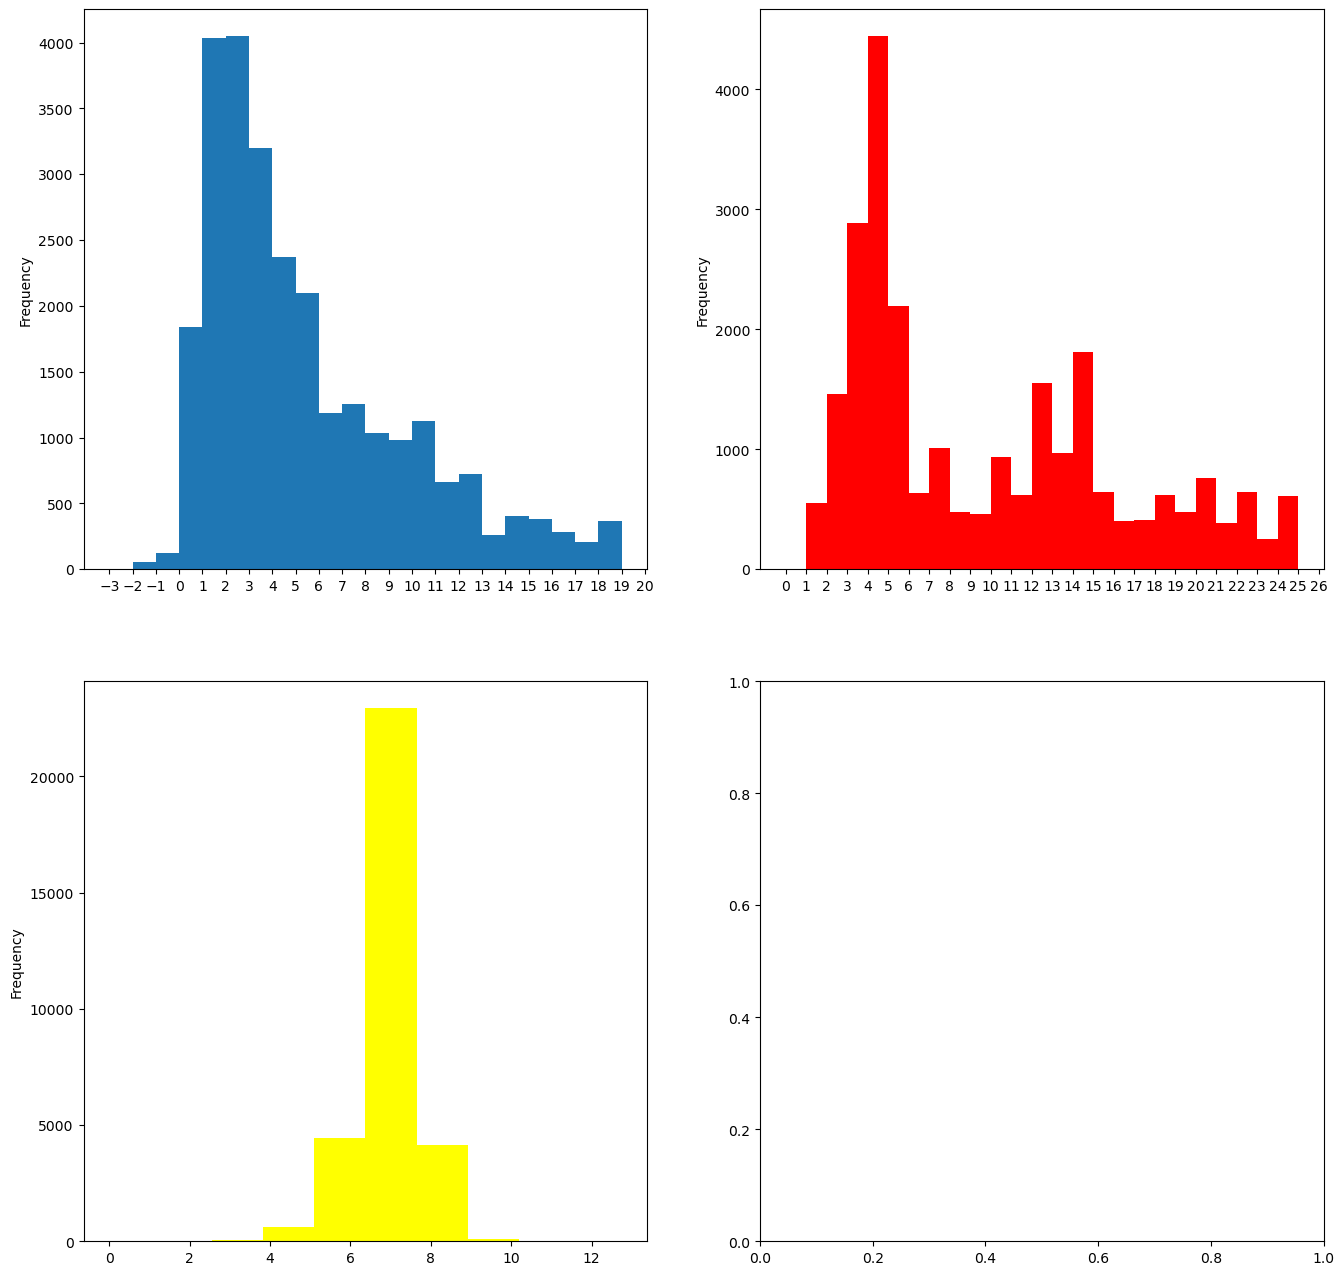

In [37]:
%matplotlib inline
fig,ax=plt.subplots(ncols=2,nrows=2,figsize=(16,16))
df['actual_floor'].plot(kind='hist',ax=ax[0][0],bins=np.arange(-3,20),xticks=np.arange(-3,21))
df['total_floor'].plot(kind='hist',ax=ax[0][1],color='red',bins=np.arange(0,26),xticks=np.arange(0,27))
np.log(df['Carpet Area']).plot(kind='hist',ax=ax[1][0],color='yellow')
plt.show()

# FILLING MISSING VALUES
1. Filling Missing Values of `Price` by median
2. Filling Missing Values of `bhk`,`bhk_type`,`Furnishing`,`Bathroom`,`TenantPreferred`,`actual_floor`,`total_floor`,`owner_type`,`Availability`,`Carpet Area` by mode
3. Drop the Society and Ownership column
4. Filling Missing values of `Balcony`,`overlooking`,`facing`,`actual_floor`,`total_floor`, with KNNImputer .*Before using knnimputer do standardization*
5. Filling missing values  `facing` with most common value within each `city` and `bhk_type`

In [38]:
df = df.drop(['Society','Ownership'], axis=1)

In [39]:
df['Price'] = df['Price'].fillna(df['Price'].median())

In [40]:
#cols = ['actual_floor','total_floor',]

#for col in cols:
#   df[col] = df[col].astype(float).fillna(df[col].mean())'''

In [41]:
df['Carpet Area'].skew()

np.float64(96.53773924930441)

In [42]:
cols = ['bhk','bhk_type','Furnishing','Bathroom','Tenant Preferred','owner_type','Availability','Carpet Area']

for col in cols:
    df[col] = df[col].fillna(df[col].mode()[0])

In [43]:
df['Carpet Area'].skew()

np.float64(96.97666887086994)

In [44]:
df.info()

<class 'pandas.core.frame.DataFrame'>
Index: 32644 entries, 8522 to 4558
Data columns (total 16 columns):
 #   Column            Non-Null Count  Dtype  
---  ------            --------------  -----  
 0   Title             32644 non-null  object 
 1   Price             32644 non-null  float64
 2   Furnishing        32644 non-null  object 
 3   Bathroom          32644 non-null  float64
 4   Tenant Preferred  32644 non-null  object 
 5   Availability      32644 non-null  object 
 6   facing            22477 non-null  object 
 7   Balcony           24242 non-null  float64
 8   Carpet Area       32644 non-null  float64
 9   overlooking       21477 non-null  object 
 10  actual_floor      27849 non-null  float64
 11  total_floor       27837 non-null  float64
 12  owner_type        32644 non-null  object 
 13  bhk               32644 non-null  float64
 14  city              32644 non-null  object 
 15  bhk_type          32644 non-null  object 
dtypes: float64(7), object(9)
memory usage: 5.2+

In [45]:
df.isnull().sum()/len(df)*100

Title                0.000000
Price                0.000000
Furnishing           0.000000
Bathroom             0.000000
Tenant Preferred     0.000000
Availability         0.000000
facing              31.145080
Balcony             25.738267
Carpet Area          0.000000
overlooking         34.208430
actual_floor        14.688764
total_floor         14.725524
owner_type           0.000000
bhk                  0.000000
city                 0.000000
bhk_type             0.000000
dtype: float64

<p style="font-size:30px;"><b>Use Capping in column Carpet Area to handle outliers and then apply KNNImputer to fill the missing values</b></p>

In [46]:
from sklearn.model_selection  import train_test_split
from sklearn.impute import KNNImputer,SimpleImputer

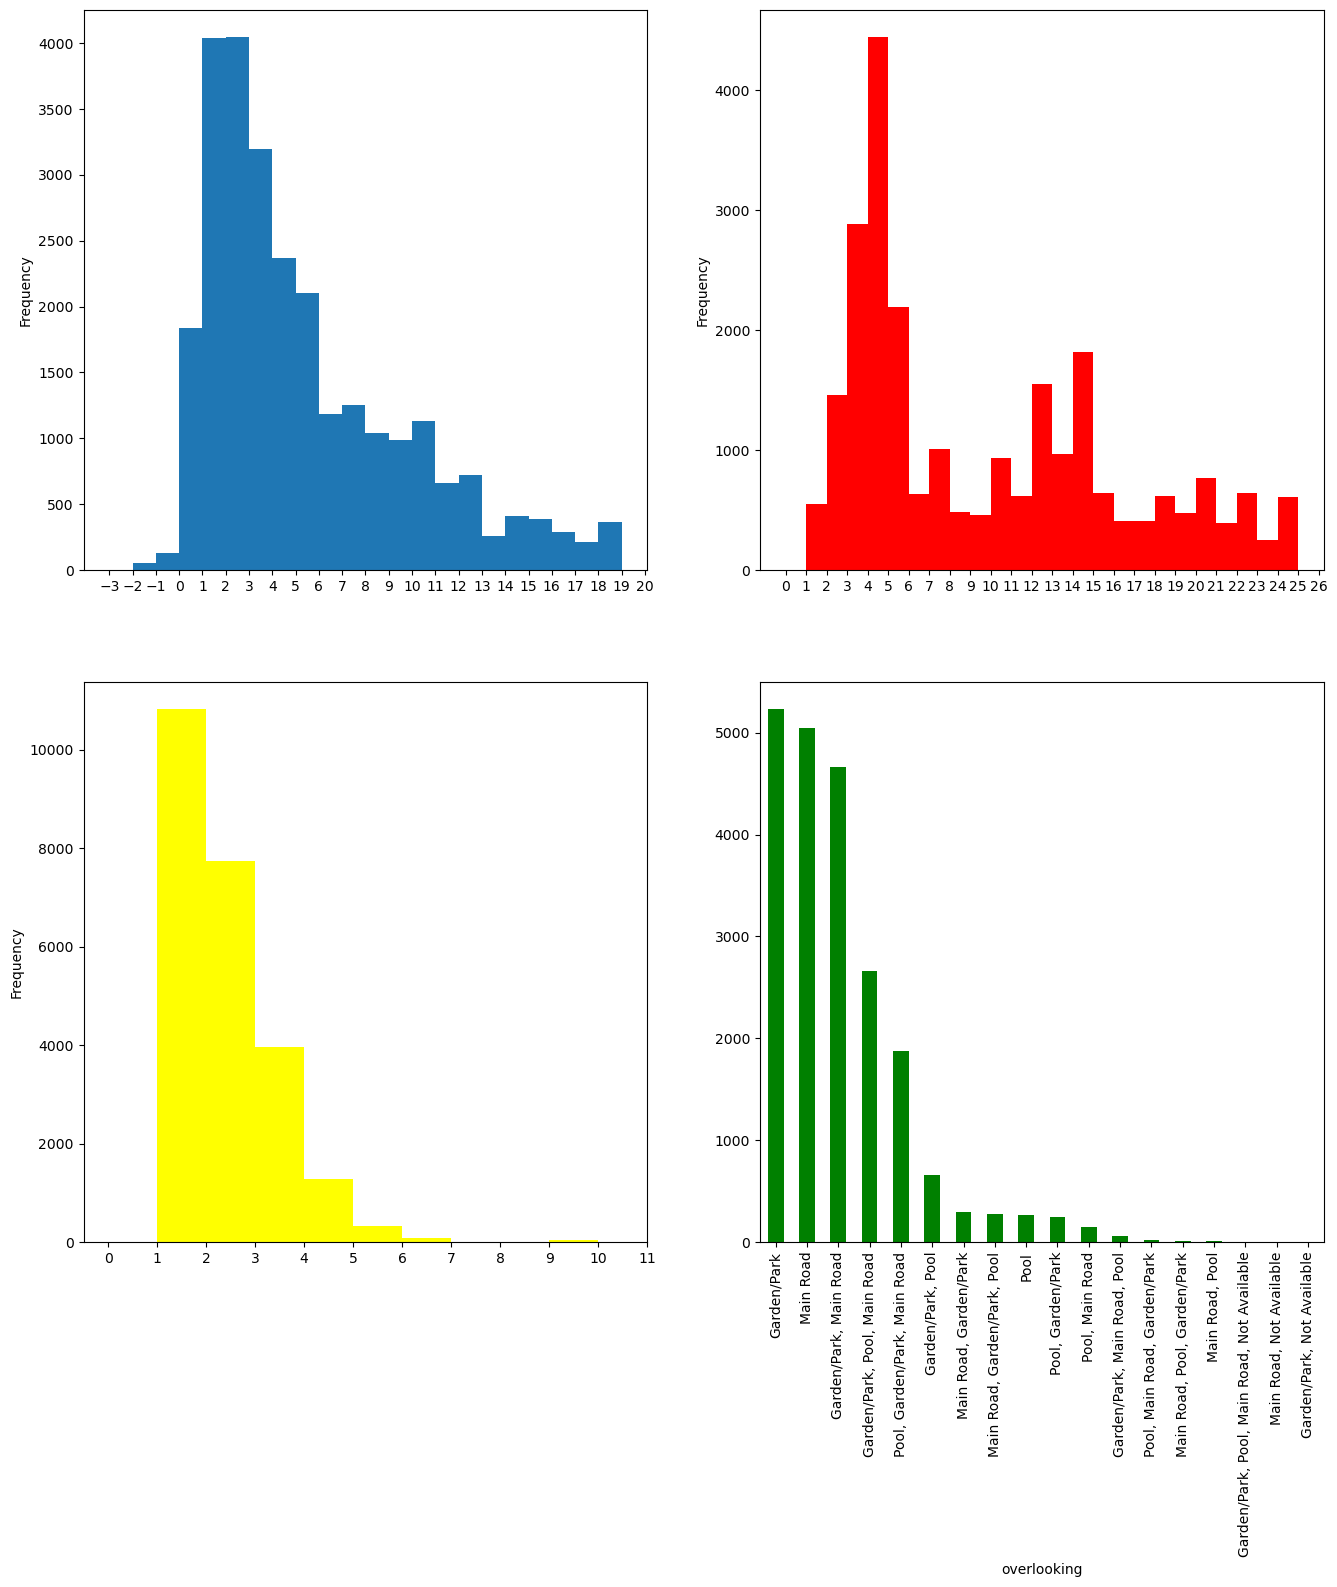

In [47]:
fig,ax=plt.subplots(ncols=2,nrows=2,figsize=(16,16))
df['actual_floor'].plot(kind='hist',ax=ax[0][0],bins=np.arange(-3,20),xticks=np.arange(-3,21))
df['total_floor'].plot(kind='hist',ax=ax[0][1],color='red',bins=np.arange(0,26),xticks=np.arange(0,27))
(df['Balcony']).plot(kind='hist',ax=ax[1][0],color='yellow',bins=np.arange(0,11),xticks=np.arange(0,12))
df['overlooking'].value_counts().plot(kind='bar',ax=ax[1][1],color='green')
plt.show()

In [48]:
from sklearn.preprocessing import StandardScaler
from sklearn.impute import KNNImputer

cols = ['actual_floor','total_floor','Balcony']

scaler = StandardScaler()
scaled = scaler.fit_transform(df[cols])

imputer = KNNImputer(n_neighbors=5)
scaled_imputed = imputer.fit_transform(scaled)

df[cols] = scaler.inverse_transform(scaled_imputed)
df[cols] = df[cols].round().astype(float)

In [49]:
# encode overlooking
df['overlooking'] = df['overlooking'].astype('category')
mapping = dict(enumerate(df['overlooking'].cat.categories))

df['overlooking'] = df['overlooking'].cat.codes
df['overlooking'] = df['overlooking'].replace(-1, np.nan)

# columns used for imputation
cols = ['overlooking','bhk','Balcony','actual_floor','total_floor']

imputer = KNNImputer(n_neighbors=5)

df[cols] = imputer.fit_transform(df[cols])

# convert to integer
df['overlooking'] = df['overlooking'].round().astype(float)

# convert back to category
df['overlooking'] = df['overlooking'].map(mapping)

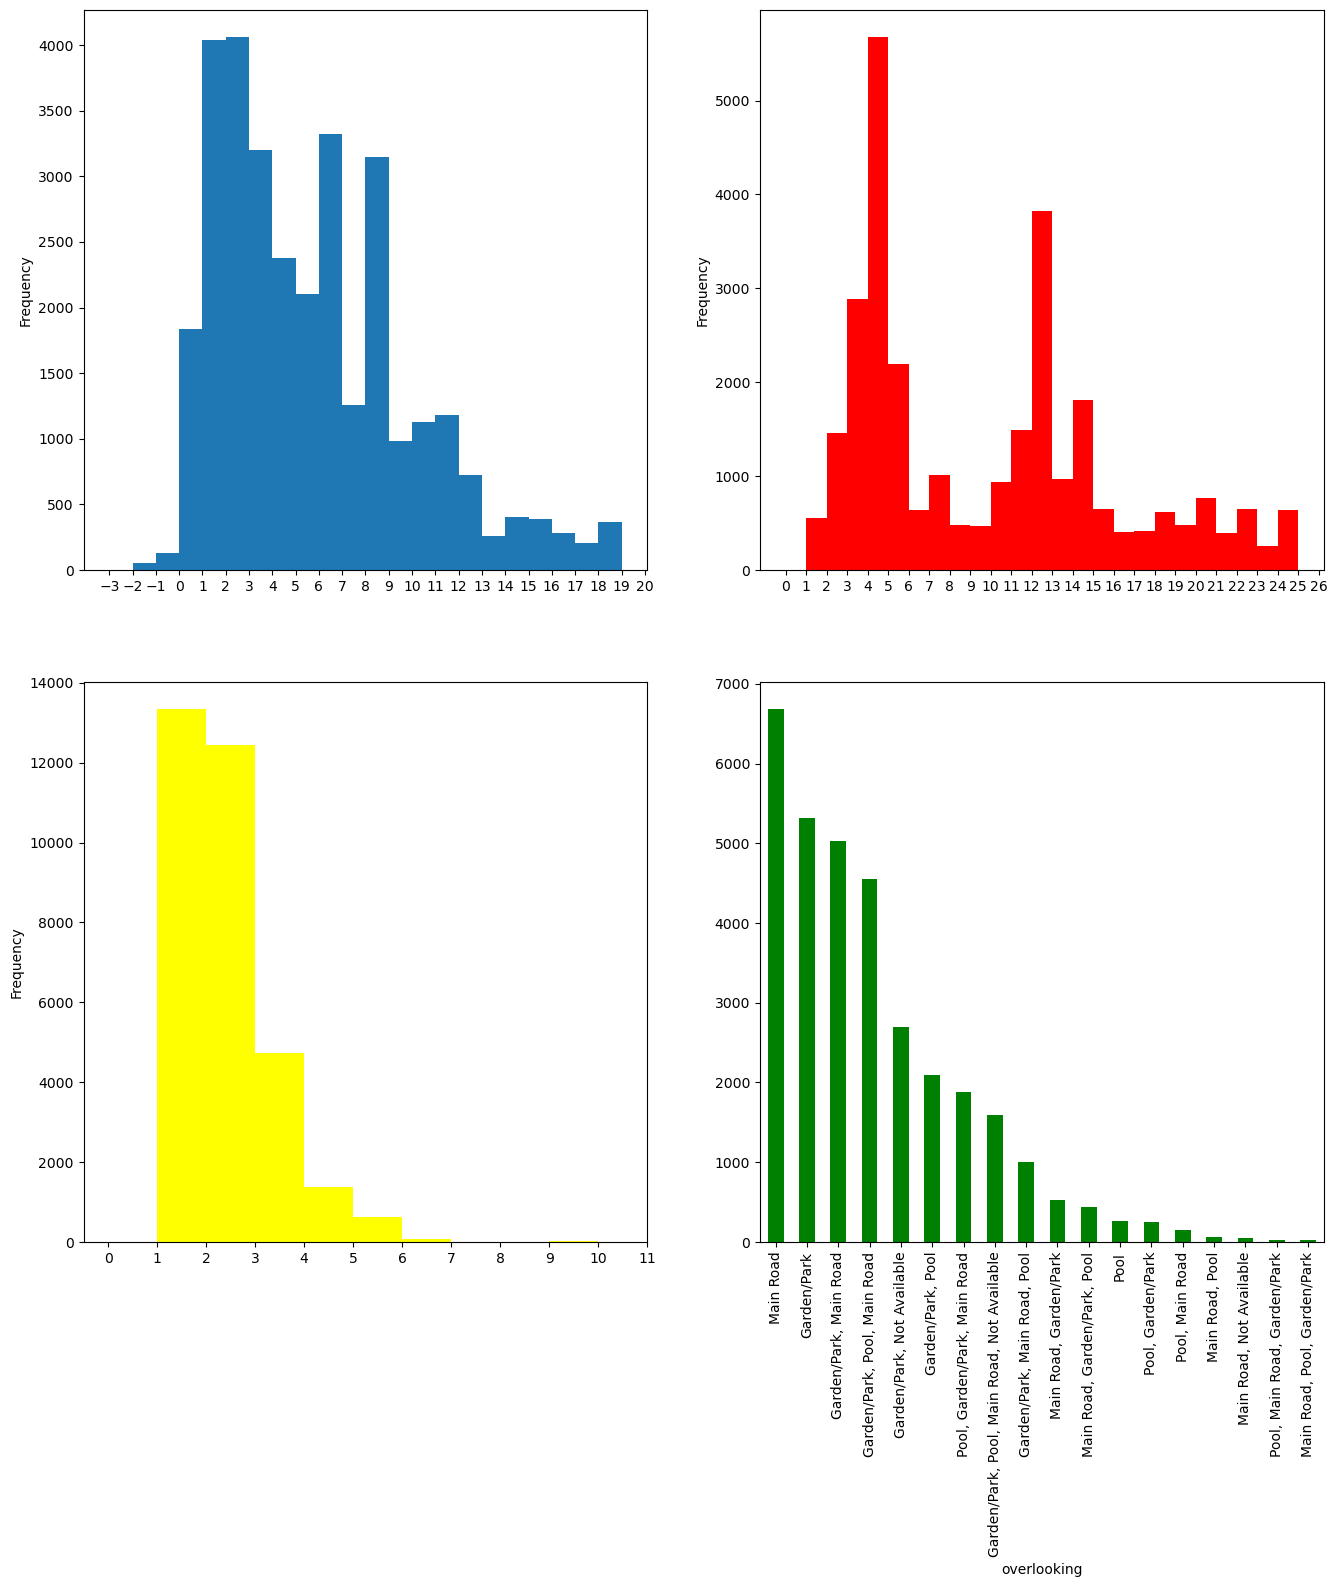

In [50]:
fig,ax=plt.subplots(ncols=2,nrows=2,figsize=(16,16))
df['actual_floor'].plot(kind='hist',ax=ax[0][0],bins=np.arange(-3,20),xticks=np.arange(-3,21))
df['total_floor'].plot(kind='hist',ax=ax[0][1],color='red',bins=np.arange(0,26),xticks=np.arange(0,27))
(df['Balcony']).plot(kind='hist',ax=ax[1][0],color='yellow',bins=np.arange(0,11),xticks=np.arange(0,12))
df['overlooking'].value_counts().plot(kind='bar',ax=ax[1][1],color='green')
plt.show()

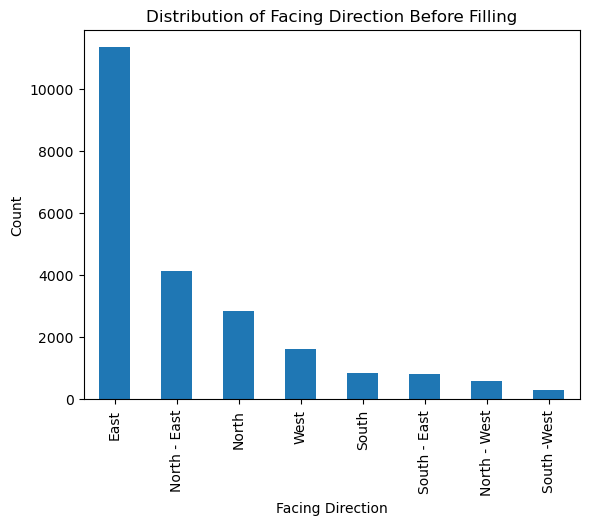

In [51]:
df['facing'].value_counts().plot(kind='bar')

plt.xlabel("Facing Direction")
plt.ylabel("Count")
plt.title("Distribution of Facing Direction Before Filling")
plt.show()

In [52]:
# fill missing facing with most common value within each city and property type

df['facing'] = df.groupby(['city','bhk_type'])['facing'].transform(
    lambda x: x.fillna(x.mode()[0] if not x.mode().empty else 'Unknown')
)

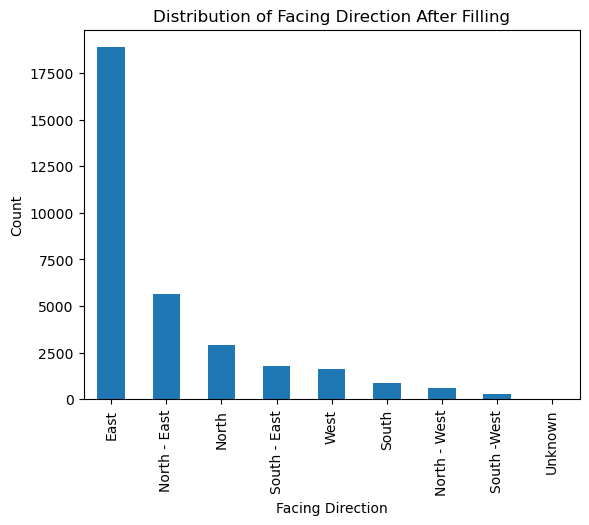

In [53]:
df['facing'].value_counts().plot(kind='bar')

plt.xlabel("Facing Direction")
plt.ylabel("Count")
plt.title("Distribution of Facing Direction After Filling")
plt.show()

In [54]:
df.isnull().sum()/len(df)*100

Title               0.0
Price               0.0
Furnishing          0.0
Bathroom            0.0
Tenant Preferred    0.0
Availability        0.0
facing              0.0
Balcony             0.0
Carpet Area         0.0
overlooking         0.0
actual_floor        0.0
total_floor         0.0
owner_type          0.0
bhk                 0.0
city                0.0
bhk_type            0.0
dtype: float64

In [55]:
df.sample(5)

,Title,Price,Furnishing,Bathroom,Tenant Preferred,Availability,facing,Balcony,Carpet Area,overlooking,actual_floor,total_floor,owner_type,bhk,city,bhk_type
17668,2 BHK Apartment for Rent in Kundrathur Chennai,7000.0,Unfurnished,1.0,Bachelors,Immediately,South,2.0,545.0,"Main Road, Garden/Park, Pool",7.0,7.0,Owner,2.0,Chennai,Apartment
1126,2 BHK Apartment for Rent in Parel Mumbai,160000.0,Semi-Furnished,2.0,Bachelors/Family,Immediately,East,3.0,708.0,Garden/Park,34.0,50.0,Agent,2.0,Mumbai,Apartment
23671,"1 BHK Apartment for Rent in Vishal Nagar, Pimp...",21000.0,Semi-Furnished,1.0,Bachelors/Family,Immediately,East,1.0,526.0,"Garden/Park, Pool, Main Road",5.0,6.0,Owner,1.0,Pune,Apartment
23774,1 BHK Apartment for Rent in Bibwewadi Pune,12000.0,Unfurnished,1.0,Bachelors/Family,Immediately,East,1.0,460.0,Main Road,2.0,4.0,Agent,1.0,Pune,Apartment
9632,1 BHK Apartment for Rent in Patel Nagar New Delhi,18500.0,Furnished,1.0,Bachelors/Family,Immediately,North - East,1.0,500.0,"Garden/Park, Main Road",2.0,4.0,Agent,1.0,Delhi,Apartment


In [56]:
profile=ProfileReport(df)
profile.to_file('report_new.html')

Summarize dataset:   0%|          | 0/5 [00:00<?, ?it/s]


%|                                                                                           | 0/16 [00:00<?, ?it/s]
100%|██████████████████████████████████████████████████████████████████████████████████| 16/16 [00:00<00:00, 45.75it/s]


Generate report structure:   0%|          | 0/1 [00:00<?, ?it/s]

Render HTML:   0%|          | 0/1 [00:00<?, ?it/s]

Export report to file:   0%|          | 0/1 [00:00<?, ?it/s]